In [1]:
%pip install -q datasets pyttsx3 seaborn tensorflow scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import string
import time
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    BatchNormalization, Activation, Add,
    GlobalAveragePooling2D, Input
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print('TensorFlow version:', tf.__version__)
print('All imports successful.')



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\raviv\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
TensorFlow version: 2.20.0
All imports successful.


In [2]:
# -----------------------------
# 1. Load Dataset
# -----------------------------
train_df = pd.read_csv("data/sign_mnist_train.csv")
test_df = pd.read_csv("data/sign_mnist_test.csv")

X_train_raw = train_df.drop("label", axis=1)
y_train_raw = train_df["label"]

X_test_raw = test_df.drop("label", axis=1)
y_test_raw = test_df["label"]

print(f'Training samples : {len(train_df):,}')
print(f'Test samples     : {len(test_df):,}')
print(f'Feature columns  : {X_train_raw.shape[1]}')
print(f'Classes          : {sorted(y_train_raw.unique())}')


Training samples : 27,455
Test samples     : 7,172
Feature columns  : 784
Classes          : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]


EXPLOTARY DATA ANALYSIS

In [3]:
# -----------------------------
# 2. Basic Dataset Information
# -----------------------------
print("\nDataset Info:")
print(train_df.info())

print("\nMissing Values Check:")
print(train_df.isnull().sum().sum())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27455 entries, 0 to 27454
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 164.4 MB
None

Missing Values Check:
0


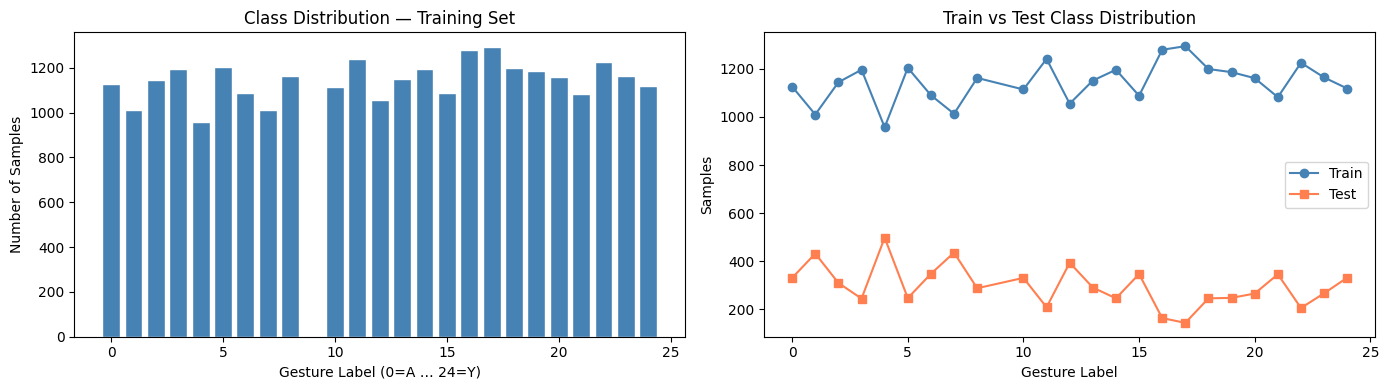

Min class count: 957  |  Max: 1294  |  Range: 337


In [4]:
# -----------------------------
# 3.2 Class Distribution
# -----------------------------
label_counts = train_df['label'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(label_counts.index, label_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Class Distribution — Training Set')
axes[0].set_xlabel('Gesture Label (0=A … 24=Y)')
axes[0].set_ylabel('Number of Samples')

train_counts = train_df['label'].value_counts().sort_index()
test_counts  = test_df['label'].value_counts().sort_index()
axes[1].plot(train_counts.index, train_counts.values, marker='o', label='Train', color='steelblue')
axes[1].plot(test_counts.index,  test_counts.values,  marker='s', label='Test',  color='coral')
axes[1].set_title('Train vs Test Class Distribution')
axes[1].set_xlabel('Gesture Label')
axes[1].set_ylabel('Samples')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f'Min class count: {label_counts.min()}  |  Max: {label_counts.max()}  |  Range: {label_counts.max()-label_counts.min()}')

The figure shows that all gesture classes contain approximately 1,000 to 1,300 samples, indicating a relatively balanced dataset. No significant class imbalance is observed, as sample counts across labels remain consistent.

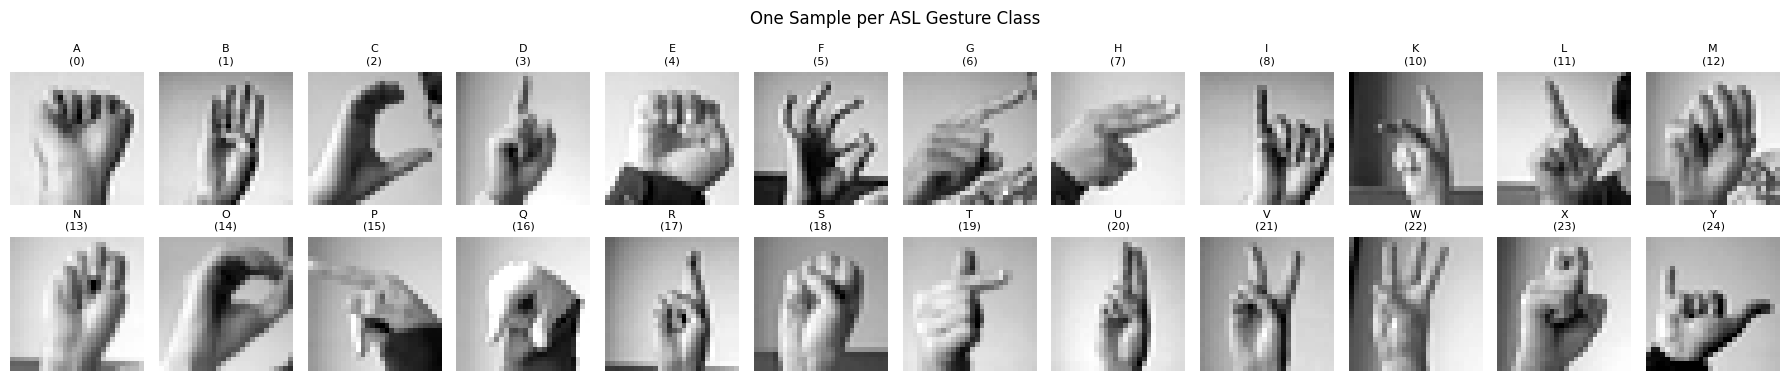

In [5]:
# -----------------------------
# 3.3 Sample Image Visualisation
# -----------------------------
letters = list(string.ascii_uppercase)
letters.remove('J')
letters.remove('Z')

fig, axes = plt.subplots(2, 12, figsize=(18, 4))
axes = axes.flatten()
for idx, label_val in enumerate(sorted(train_df['label'].unique())):
    sample = train_df[train_df['label'] == label_val].iloc[0]
    img = sample.drop('label').values.reshape(28, 28)
    axes[idx].imshow(img, cmap='gray')
    axes[idx].set_title(f'{letters[idx]}\n({label_val})', fontsize=8)
    axes[idx].axis('off')
plt.suptitle('One Sample per ASL Gesture Class', fontsize=12)
plt.tight_layout()
plt.show()

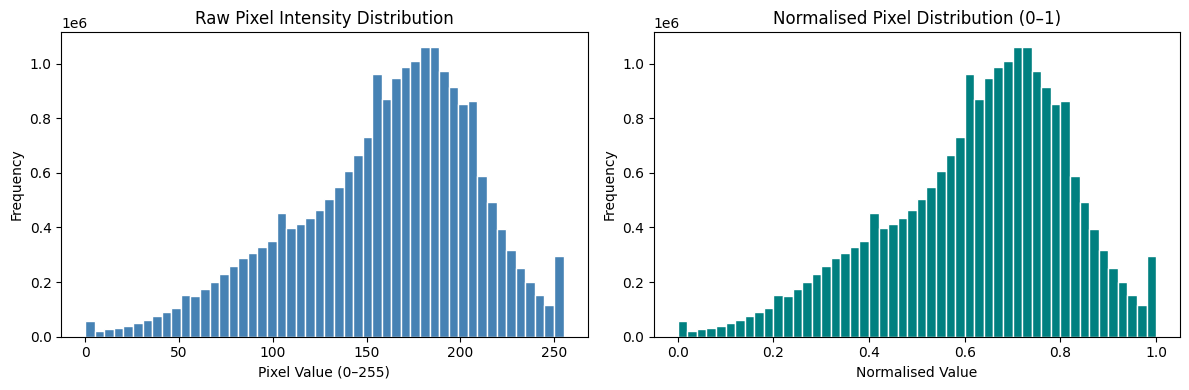

Mean: 159.29  |  Std: 48.77  |  Min: 0  |  Max: 255


In [6]:
# -----------------------------
# 3.4 Pixel Intensity Analysis
# -----------------------------
pixels = X_train_raw.values.flatten()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(pixels, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Raw Pixel Intensity Distribution')
axes[0].set_xlabel('Pixel Value (0–255)')
axes[0].set_ylabel('Frequency')

norm_pixels = pixels / 255.0
axes[1].hist(norm_pixels, bins=50, color='teal', edgecolor='white')
axes[1].set_title('Normalised Pixel Distribution (0–1)')
axes[1].set_xlabel('Normalised Value')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f'Mean: {np.mean(pixels):.2f}  |  Std: {np.std(pixels):.2f}  |  Min: {np.min(pixels)}  |  Max: {np.max(pixels)}')

This plot illustrates the distribution of grayscale pixel intensities across the ASL-MNIST training dataset. Pixel values range from 0 (black) to 255 (white), representing different brightness levels within the images.

The histogram indicates that most pixel values are concentrated between approximately 100 and 200, with a peak around 160–180. This suggests that a large portion of the image content corresponds to mid-to-high intensity values, which primarily represent the hand regions. Lower pixel values correspond to darker background areas.

Very few pixels are observed at extreme intensity levels, indicating the absence of overexposed or underexposed images. The smooth distribution demonstrates consistent lighting conditions and good dataset quality.

This analysis confirms sufficient contrast between foreground and background regions, which is beneficial for feature extraction. Furthermore, it justifies the application of pixel normalization prior to model training to improve numerical stability and learning efficiency.

In [8]:
# -----------------------------
# 6. Image Dimension Verification
# -----------------------------
image_shape = X_train.iloc[0].values.reshape(28, 28).shape
print("\nImage Shape:", image_shape)



Image Shape: (28, 28)


To confirm the consistency of image dimensions within the dataset, a sample image was reshaped from its flattened representation into a two-dimensional format. The resulting shape was verified as 28 × 28 pixels.

This verification step ensures that all images conform to the expected input size required for convolutional neural networks. Uniform image dimensions are essential for batch processing and model training, as inconsistent shapes can lead to computational errors and degraded performance.

The confirmed image size aligns with the ASL-MNIST dataset specifications and supports the suitability of the dataset for CNN-based gesture recognition.

The class-wise statistical analysis confirms distinct pixel intensity patterns across gestures and demonstrates adequate variability without excessive noise, providing a reliable foundation for deep learning model training.

PREPROCESSING

In [7]:
# -----------------------------
# 4.1 Label Encoding
# -----------------------------
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train_raw)   # integers 0–23
y_test_enc  = le.transform(y_test_raw)

# One-hot encode for deep learning models
y_train_cat = to_categorical(y_train_enc)     # shape (N, 24)
y_test_cat  = to_categorical(y_test_enc)

print(f'Encoded label range : {y_train_enc.min()} – {y_train_enc.max()}')
print(f'One-hot shape       : {y_train_cat.shape}')

Encoded label range : 0 – 23
One-hot shape       : (27455, 24)


In [8]:
# -----------------------------
# 4.2 Reshape & Normalise for CNN models (28x28x1, range 0–1)
# -----------------------------
X_train = X_train_raw.values.reshape(-1, 28, 28, 1) / 255.0
X_test  = X_test_raw.values.reshape(-1, 28, 28, 1)  / 255.0

# Flat version for sklearn baseline models
X_train_flat = X_train_raw.values / 255.0    # shape (27455, 784)
X_test_flat  = X_test_raw.values  / 255.0

print(f'CNN input shape     : {X_train.shape}')
print(f'Flat input shape    : {X_train_flat.shape}')

CNN input shape     : (27455, 28, 28, 1)
Flat input shape    : (27455, 784)


In [9]:
# -----------------------------
# 4.3 Preprocess for EfficientNetB0 (64x64x3, range 0–255)
# -----------------------------
def preprocess_for_efficientnet(X, img_size=64):
    X_resized = tf.image.resize(X, [img_size, img_size])   # (N, 64, 64, 1)
    X_rgb     = tf.repeat(X_resized, 3, axis=-1)           # (N, 64, 64, 3)
    return (X_rgb * 255.0).numpy()                         # back to 0–255

print('Preparing EfficientNetB0 inputs...')
X_train_eff = preprocess_for_efficientnet(X_train)
X_test_eff  = preprocess_for_efficientnet(X_test)
print(f'EfficientNet input shape: {X_train_eff.shape}')

Preparing EfficientNetB0 inputs...
EfficientNet input shape: (27455, 64, 64, 3)


In [10]:
# -----------------------------
# 4.4 Data Augmentation Generator (used by CNN, ResNet, EfficientNet)
# Note: horizontal_flip=False — flipping changes ASL hand meaning
# -----------------------------
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=False,
    validation_split=0.1
)

def make_generators(X, y, batch_size=64):
    train_gen = datagen.flow(X, y, batch_size=batch_size, subset='training',   seed=42)
    val_gen   = datagen.flow(X, y, batch_size=batch_size, subset='validation', seed=42)
    return train_gen, val_gen

print('Augmentation generator ready.')

Augmentation generator ready.


5.Baseline Models - Random Forest and SVM

In [11]:
# -----------------------------
# 5.1 Random Forest
# -----------------------------
print('Training Random Forest (n_estimators=200)...')
t0 = time.time()

rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_flat, y_train_enc)

rf_time = time.time() - t0
rf_preds = rf.predict(X_test_flat)
rf_acc   = accuracy_score(y_test_enc, rf_preds)

print(f'Random Forest Accuracy : {rf_acc:.4f} ({rf_acc*100:.2f}%)')
print(f'Training time          : {rf_time:.1f}s')
print('\nClassification Report:')
print(classification_report(y_test_enc, rf_preds, target_names=letters))

Training Random Forest (n_estimators=200)...
Random Forest Accuracy : 0.8211 (82.11%)
Training time          : 15.1s

Classification Report:
              precision    recall  f1-score   support

           A       0.93      1.00      0.96       331
           B       0.98      0.94      0.96       432
           C       0.96      1.00      0.98       310
           D       0.89      0.99      0.94       245
           E       0.90      0.99      0.94       498
           F       0.94      0.91      0.93       247
           G       0.93      0.86      0.89       348
           H       0.99      0.94      0.97       436
           I       0.83      0.80      0.82       288
           K       0.73      0.65      0.69       331
           L       0.82      1.00      0.90       209
           M       0.84      0.69      0.76       394
           N       0.82      0.54      0.65       291
           O       1.00      0.92      0.96       246
           P       0.93      1.00      0.97     

The labels were first converted into numerical format using LabelEncoder to make them compatible with machine learning algorithms. The images were reshaped into 28×28 grayscale format to match CNN input requirements. Pixel normalization was applied to scale values between 0 and 1 to improve convergence. Finally, one-hot encoding was used to convert class labels into categorical vectors suitable for softmax classification. If you do not one-hot encode:
    Shape mismatch error
    Incorrect loss calculation

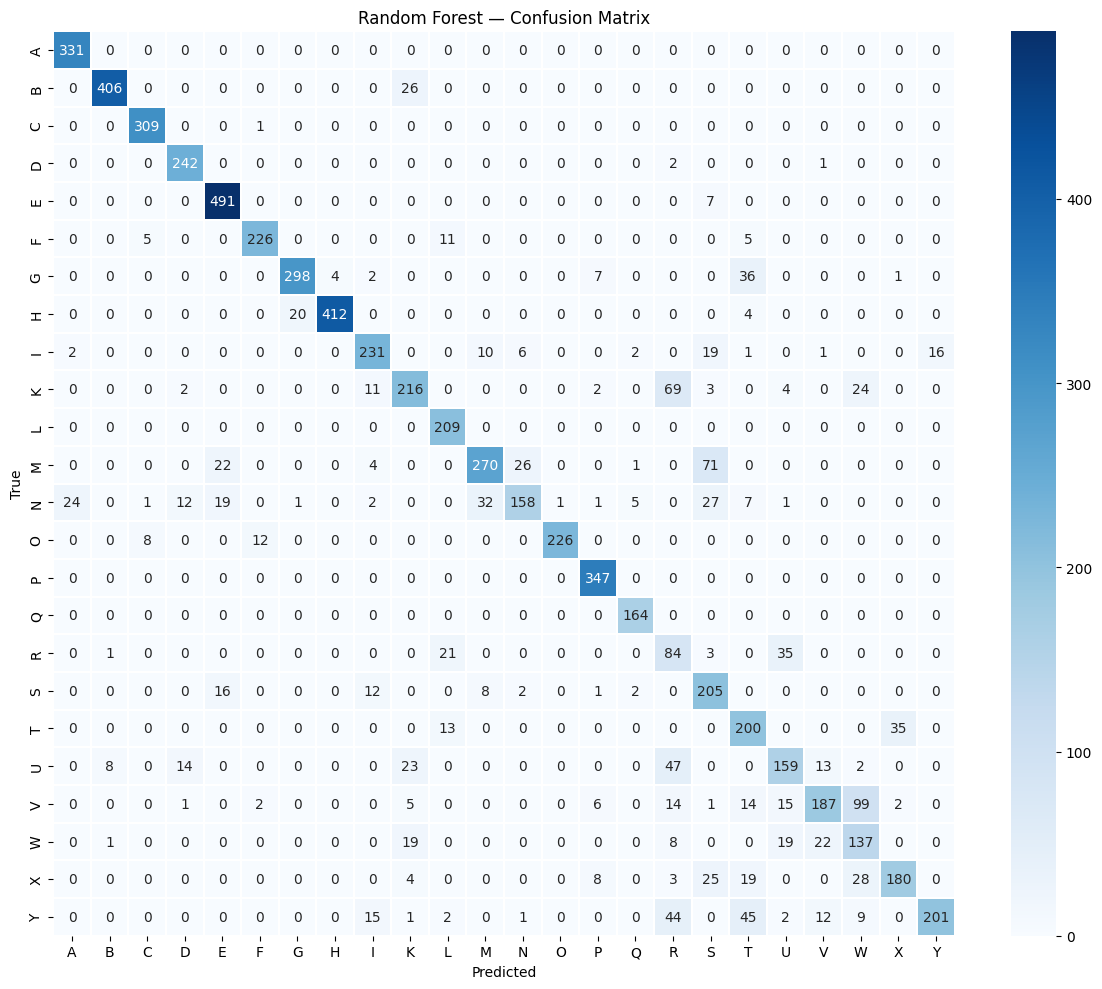

In [12]:
# Confusion Matrix — Random Forest
cm_rf = confusion_matrix(y_test_enc, rf_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_rf, annot=True, fmt='d', linewidth=0.2,
            xticklabels=letters, yticklabels=letters, cmap='Blues')
plt.title('Random Forest — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

In [13]:
# -----------------------------
# 5.2 Support Vector Machine (RBF kernel)
# -----------------------------
print('Training SVM (RBF kernel, C=10)...')
t0 = time.time()

svm = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm.fit(X_train_flat, y_train_enc)

svm_time  = time.time() - t0
svm_preds = svm.predict(X_test_flat)
svm_acc   = accuracy_score(y_test_enc, svm_preds)

print(f'SVM Accuracy    : {svm_acc:.4f} ({svm_acc*100:.2f}%)')
print(f'Training time   : {svm_time:.1f}s')
print('\nClassification Report:')
print(classification_report(y_test_enc, svm_preds, target_names=letters))

Training SVM (RBF kernel, C=10)...
SVM Accuracy    : 0.8371 (83.71%)
Training time   : 84.8s

Classification Report:
              precision    recall  f1-score   support

           A       0.90      1.00      0.95       331
           B       1.00      0.99      1.00       432
           C       0.85      0.99      0.92       310
           D       0.94      1.00      0.97       245
           E       0.95      1.00      0.97       498
           F       0.71      0.83      0.77       247
           G       0.93      0.93      0.93       348
           H       0.99      0.93      0.96       436
           I       0.80      0.87      0.83       288
           K       0.75      0.54      0.63       331
           L       0.90      0.96      0.93       209
           M       0.84      0.74      0.78       394
           N       0.90      0.66      0.76       291
           O       1.00      0.83      0.90       246
           P       1.00      1.00      1.00       347
           Q      

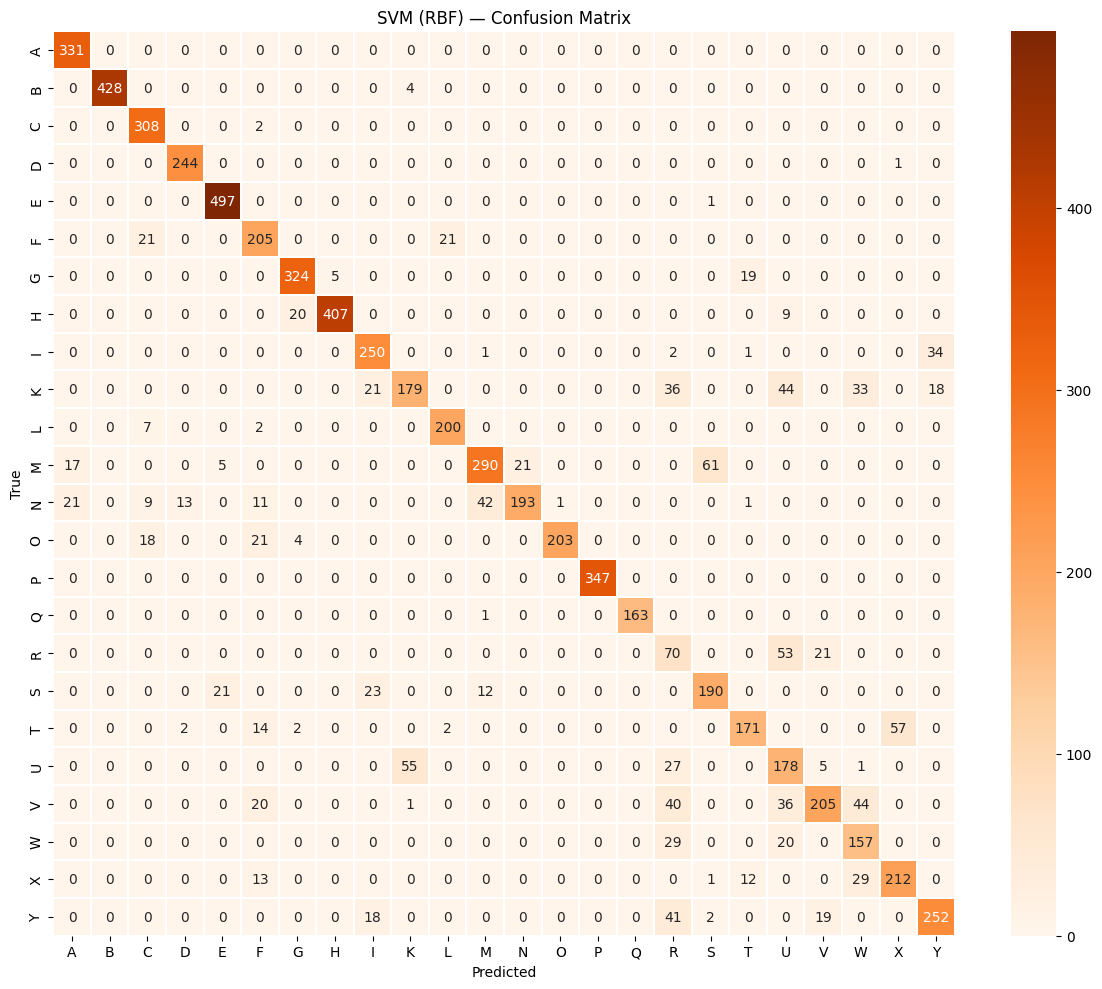

In [14]:
# Confusion Matrix — SVM
cm_svm = confusion_matrix(y_test_enc, svm_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm_svm, annot=True, fmt='d', linewidth=0.2,
            xticklabels=letters, yticklabels=letters, cmap='Oranges')
plt.title('SVM (RBF) — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

6.Custom CNN with Hyperparameter Grid Search

In [15]:
# -----------------------------
# 6.1 Model Definition
# -----------------------------
def create_cnn(dropout_rate=0.5):
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(28, 28, 1)),
        MaxPooling2D(),
        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(dropout_rate),
        Dense(24, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

create_cnn().summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         3,096 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 226,840 (886.09 KB)

 Trainable params: 226,840 (886.09 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# -----------------------------
# 6.2 Hyperparameter Grid Search
# -----------------------------
batch_sizes   = [32, 64]
epochs_list   = [10, 15]
dropouts      = [0.3, 0.5]

cnn_results   = []
best_cnn_acc  = 0
best_cnn_model = None
best_cnn_history = None

for batch in batch_sizes:
    for epochs in epochs_list:
        for dropout in dropouts:
            print(f'  batch={batch}, epochs={epochs}, dropout={dropout}', end=' ... ')
            model = create_cnn(dropout)
            history = model.fit(
                X_train, y_train_cat,
                epochs=epochs,
                batch_size=batch,
                validation_split=0.1,
                verbose=0
            )
            _, acc = model.evaluate(X_test, y_test_cat, verbose=0)
            cnn_results.append({'batch': batch, 'epochs': epochs, 'dropout': dropout, 'accuracy': acc})
            print(f'acc={acc:.4f}')
            if acc > best_cnn_acc:
                best_cnn_acc     = acc
                best_cnn_model   = model
                best_cnn_history = history

cnn_df = pd.DataFrame(cnn_results).sort_values('accuracy', ascending=False)
print('\nGrid Search Results:')
print(cnn_df.to_string(index=False))
print(f'\nBest CNN Accuracy: {best_cnn_acc:.4f}')



  batch=32, epochs=10, dropout=0.3 ... acc=0.9399
  batch=32, epochs=10, dropout=0.5 ... acc=0.9293
  batch=32, epochs=15, dropout=0.3 ... acc=0.9448
  batch=32, epochs=15, dropout=0.5 ... acc=0.9366
  batch=64, epochs=10, dropout=0.3 ... acc=0.9322
  batch=64, epochs=10, dropout=0.5 ... acc=0.9347
  batch=64, epochs=15, dropout=0.3 ... acc=0.9350
  batch=64, epochs=15, dropout=0.5 ... acc=0.9347

Grid Search Results:
 batch  epochs  dropout  accuracy
    32      15      0.3  0.944785
    32      10      0.3  0.939905
    32      15      0.5  0.936559
    64      15      0.3  0.935025
    64      15      0.5  0.934746
    64      10      0.5  0.934746
    64      10      0.3  0.932236
    32      10      0.5  0.929308

Best CNN Accuracy: 0.9448


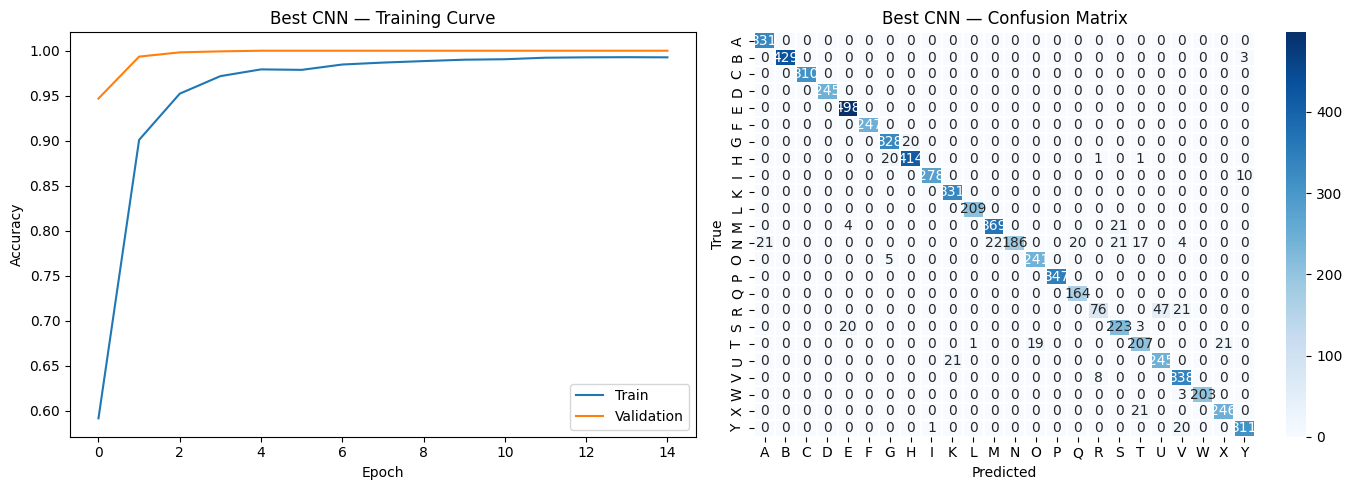


Classification Report (Best CNN):
              precision    recall  f1-score   support

           A       0.94      1.00      0.97       331
           B       1.00      0.99      1.00       432
           C       1.00      1.00      1.00       310
           D       1.00      1.00      1.00       245
           E       0.95      1.00      0.98       498
           F       1.00      1.00      1.00       247
           G       0.93      0.94      0.94       348
           H       0.95      0.95      0.95       436
           I       1.00      0.97      0.98       288
           K       0.94      1.00      0.97       331
           L       1.00      1.00      1.00       209
           M       0.94      0.94      0.94       394
           N       1.00      0.64      0.78       291
           O       0.93      0.98      0.95       246
           P       1.00      1.00      1.00       347
           Q       0.89      1.00      0.94       164
           R       0.89      0.53      0.66   

In [17]:
# -----------------------------
# 6.3 Best CNN — Evaluation
# -----------------------------
cnn_preds = np.argmax(best_cnn_model.predict(X_test, verbose=0), axis=1)
y_true    = np.argmax(y_test_cat, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training curve
axes[0].plot(best_cnn_history.history['accuracy'],     label='Train')
axes[0].plot(best_cnn_history.history['val_accuracy'], label='Validation')
axes[0].set_title('Best CNN — Training Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Confusion matrix
cm_cnn = confusion_matrix(y_true, cnn_preds)
sns.heatmap(cm_cnn, ax=axes[1], annot=True, fmt='d', linewidth=0.2,
            xticklabels=letters, yticklabels=letters, cmap='Blues')
axes[1].set_title('Best CNN — Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

print('\nClassification Report (Best CNN):')
print(classification_report(y_true, cnn_preds, target_names=letters))

Convolutional Neural Network (CNN) built using a Sequential architecture, where layers are stacked one after another. It begins with two convolutional layers (32 and 64 filters of size 3×3) with ReLU activation to automatically extract important visual features from 28×28 grayscale hand gesture images. Each convolution layer is followed by MaxPooling to reduce spatial dimensions and computational complexity while retaining key features. The extracted feature maps are then flattened into a one-dimensional vector and passed to a fully connected Dense layer with 128 neurons to learn high-level patterns. A Dropout layer (50%) is used to prevent overfitting by randomly disabling neurons during training. Finally, a Dense output layer with 24 neurons and softmax activation produces probability scores for each ASL alphabet class, enabling multi-class gesture classification.

The model has 226,840 total trainable parameters, meaning all weights are updated during training. Most parameters (204,928) are in the fully connected Dense layer, which typically contains the largest number of learnable weights. There are no non-trainable parameters, indicating the entire network participates in learning.

Overall, this is a well-structured CNN suitable for ASL gesture classification.

7. ResNet - style Model with Skip Connections

In [18]:
# -----------------------------
# 7.1 Residual Block Definition
# -----------------------------

def residual_block(x, filters, stride=1,downsample=False):
    shortcut = x
    

    x = Conv2D(filters, (3, 3), strides=stride, padding='same',use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(filters, (3, 3),strides=1, padding='same',use_bias=False)(x)
    x = BatchNormalization()(x)

    if downsample or shortcut.shape[-1] != filters:
        shortcut = Conv2D(filters, (1, 1), strides=stride, padding='same',use_bias=False)(shortcut)
        shortcut = BatchNormalization()(shortcut)

    x = Add()([shortcut, x])
    x = Activation('relu')(x)
    return x

In [23]:
# -----------------------------
# 7.2 ResNet-18 Architecture
# -----------------------------

def build_resnet(input_shape=(28, 28, 1), num_classes=24):
    inputs = Input(shape=input_shape)
    x = Conv2D(32, (3, 3), padding='same', use_bias=False)(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((3, 3), strides=2, padding='same')(x)

    # Layer 1 -32 layers
    x = residual_block(x, 32)
    x = residual_block(x, 32)

    # Layer 2 - 64 layers
    x = residual_block(x, 64, stride=2, downsample=True)
    x = residual_block(x, 64)

    # Layer 3 -128 layers
    x = residual_block(x, 128, stride=2, downsample=True)
    x = residual_block(x, 128)


    x = GlobalAveragePooling2D()(x)
    x = Dense(256,activation='relu')(x)
    x = Dropout(0.4)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model
resnet_model = build_resnet()
resnet_model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_33 (Conv2D)  │ (None, 28, 28,    │        288 │ input_layer_10[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        128 │ conv2d_33[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_13       │ (None, 28, 28,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_19    │ (None, 14, 14,    │          0 │ activation_13[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_34 (Conv2D)  │ (None, 14, 14,    │      9,216 │ max_pooling2d_19… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        128 │ conv2d_34[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_14       │ (None, 14, 14,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_35 (Conv2D)  │ (None, 14, 14,    │      9,216 │ activation_14[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        128 │ conv2d_35[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 14, 14,    │          0 │ max_pooling2d_19… │
│                     │ 32)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_15       │ (None, 14, 14,    │          0 │ add_6[0][0]       │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_36 (Conv2D)  │ (None, 14, 14,    │      9,216 │ activation_15[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        128 │ conv2d_36[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_16       │ (None, 14, 14,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_37 (Conv2D)  │ (None, 14, 14,    │      9,216 │ activation_16[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        128 │ conv2d_37[0][0] 

 Total params: 736,184 (2.81 MB)

 Trainable params: 733,944 (2.80 MB)

 Non-trainable params: 2,240 (8.75 KB)

In [24]:
# -----------------------------
# 7.3 Phase 1: Train ResNet
# -----------------------------

callbacks_resnet = [
    EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3,min_lr=1e-6, verbose=1 )]
train_gen_r, val_gen_r = make_generators(X_train, y_train_cat, batch_size=64)
print('Phase: 1 Training ResNet-18 from scratch...')

t0 = time.time()
history_resnet= resnet_model.fit(
    train_gen_r,
    validation_data=val_gen_r,
    epochs=40,
    callbacks=callbacks_resnet,
    verbose=1
)
resnet_time = time.time() - t0
_, resnet_acc = resnet_model.evaluate(X_test, y_test_cat, verbose=0)
print(f'\nResNet Accuracy : {resnet_acc:.4f} ({resnet_acc*100:.2f}%)')
print(f'Training time   : {resnet_time/60:.1f} min')

Phase: 1 Training ResNet-18 from scratch...
Epoch 1/40
387/387 ━━━━━━━━━━━━━━━━━━━━ 33s 71ms/step - accuracy: 0.7336 - loss: 0.8130 - val_accuracy: 0.2353 - val_loss: 3.4976 - learning_rate: 0.0010
Epoch 2/40
387/387 ━━━━━━━━━━━━━━━━━━━━ 30s 77ms/step - accuracy: 0.9593 - loss: 0.1260 - val_accuracy: 0.9206 - val_loss: 0.2560 - learning_rate: 0.0010
Epoch 3/40
387/387 ━━━━━━━━━━━━━━━━━━━━ 30s 79ms/step - accuracy: 0.9760 - loss: 0.0782 - val_accuracy: 0.8987 - val_loss: 0.3516 - learning_rate: 0.0010
Epoch 4/40
387/387 ━━━━━━━━━━━━━━━━━━━━ 31s 80ms/step - accuracy: 0.9848 - loss: 0.0514 - val_accuracy: 0.2474 - val_loss: 9.2952 - learning_rate: 0.0010
Epoch 5/40
387/387 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.9705 - loss: 0.0928
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
387/387 ━━━━━━━━━━━━━━━━━━━━ 32s 83ms/step - accuracy: 0.9826 - loss: 0.0573 - val_accuracy: 0.9155 - val_loss: 0.3444 - learning_rate: 0.0010
Epoch 6/40
387/387 ━━━━━━━━━━━━━━━

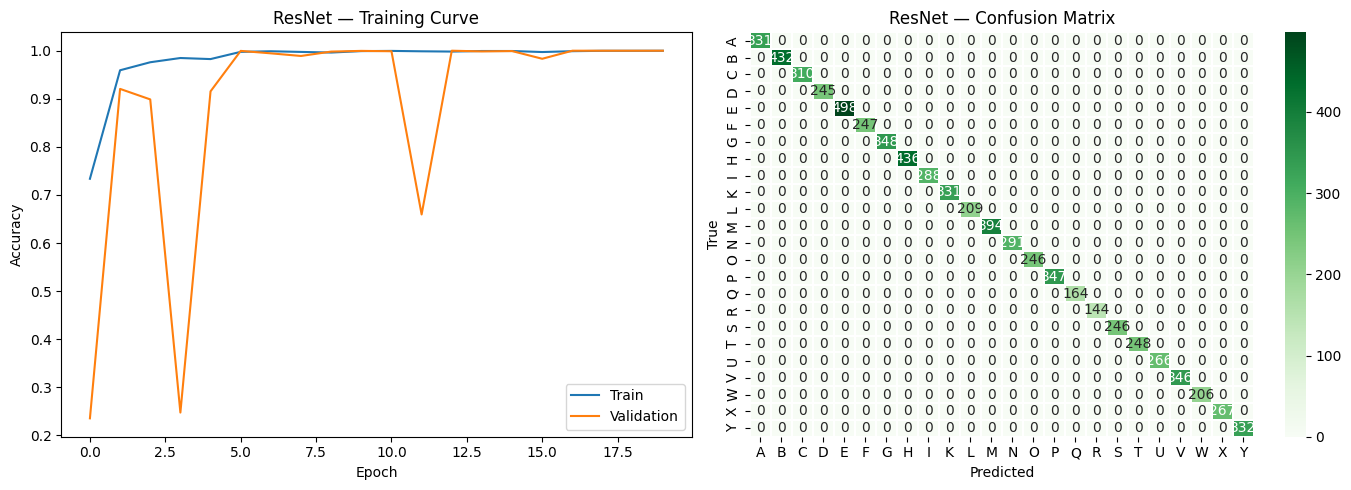


Classification Report (ResNet):
              precision    recall  f1-score   support

           A       1.00      1.00      1.00       331
           B       1.00      1.00      1.00       432
           C       1.00      1.00      1.00       310
           D       1.00      1.00      1.00       245
           E       1.00      1.00      1.00       498
           F       1.00      1.00      1.00       247
           G       1.00      1.00      1.00       348
           H       1.00      1.00      1.00       436
           I       1.00      1.00      1.00       288
           K       1.00      1.00      1.00       331
           L       1.00      1.00      1.00       209
           M       1.00      1.00      1.00       394
           N       1.00      1.00      1.00       291
           O       1.00      1.00      1.00       246
           P       1.00      1.00      1.00       347
           Q       1.00      1.00      1.00       164
           R       1.00      1.00      1.00     

In [25]:
# -----------------------------
# 7.4 ResNet — Evaluation
# -----------------------------
resnet_preds = np.argmax(resnet_model.predict(X_test, verbose=0), axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_resnet.history['accuracy'],     label='Train')
axes[0].plot(history_resnet.history['val_accuracy'], label='Validation')
axes[0].set_title('ResNet — Training Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

cm_resnet = confusion_matrix(y_true, resnet_preds)
sns.heatmap(cm_resnet, ax=axes[1], annot=True, fmt='d', linewidth=0.2,
            xticklabels=letters, yticklabels=letters, cmap='Greens')
axes[1].set_title('ResNet — Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

print('\nClassification Report (ResNet):')
print(classification_report(y_true, resnet_preds, target_names=letters))

Predicted Letter: G
Current Word: G


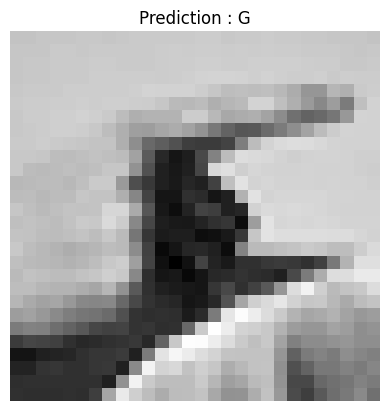

Predicted Letter: F
Current Word: GF


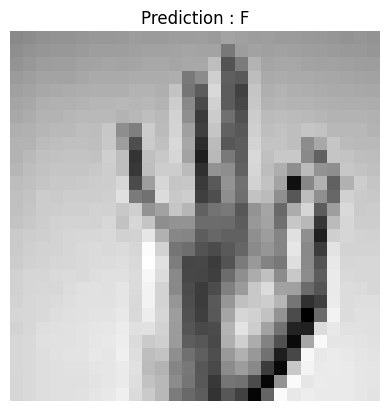

Predicted Letter: K
Current Word: GFK


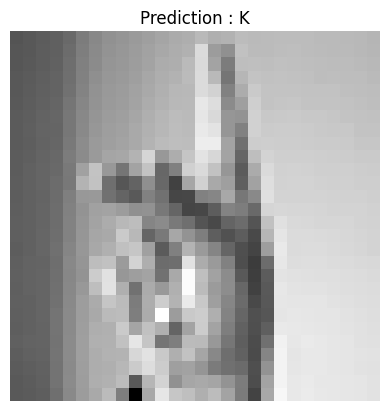

Predicted Letter: A
Current Word: GFKA


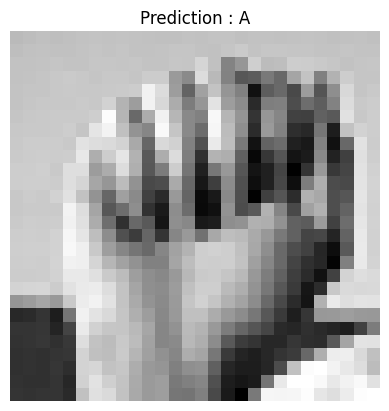

Predicted Letter: D
Current Word: GFKAD


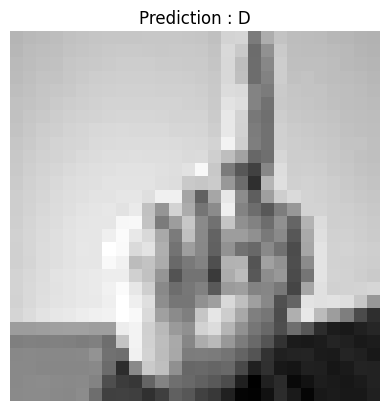

Predicted Letter: V
Current Word: GFKADV


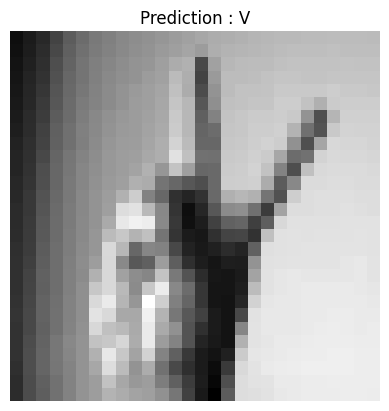

Predicted Letter: K
Current Word: GFKADVK


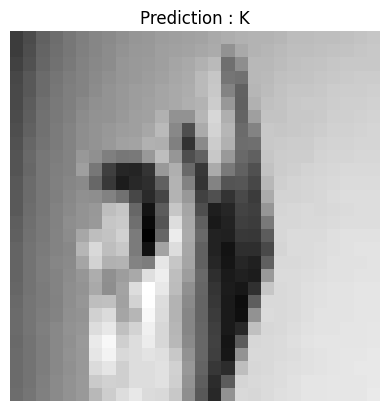

Predicted Letter: O
Current Word: GFKADVKO


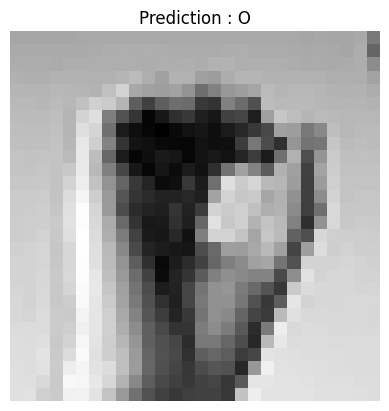

Predicted Letter: D
Current Word: GFKADVKOD


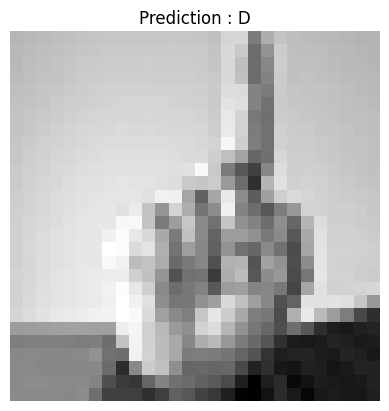

Predicted Letter: H
Current Word: GFKADVKODH


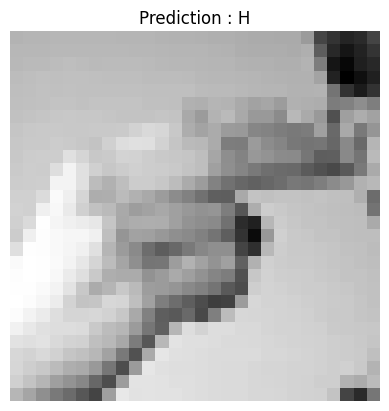

In [22]:

# Letter Mapping

letters = list(string.ascii_uppercase)

# Remove motion letters
letters.remove('J')
letters.remove('Z')


#  Word Builder

current_word = ""
last_letter = None

def update_word(letter):
    global current_word,last_letter

    if letter != last_letter:
        current_word += letter
        last_letter = letter

    print("Predicted Letter:",letter)
    print("Current Word:",current_word)


#  Prediction Function

def predict_letter(image):

    img = image.reshape(1,28,28,1)
    prediction = model.predict(img,verbose=0)

    class_index = np.argmax(prediction)
    letter = letters[class_index]

    return letter


#  Show Image + Prediction

for i in range(10):

    image = X_test[i]

    letter = predict_letter(image)

    update_word(letter)

    plt.imshow(image.reshape(28,28),cmap='gray')
    plt.title(f"Prediction : {letter}")
    plt.axis("off")
    plt.show()



In [25]:
# Optional Speech (Assistive Feature)

try:
    import pyttsx3

    engine = pyttsx3.init()

    def speak():
        engine.say(current_word)
        engine.runAndWait()

    speak()
    print("Spoken Word:", current_word)

except:
    print("Speech module not installed")

Spoken Word: GFKADVKODH
